In [4]:
from pathlib import Path
import csv

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils
from tqdm import tqdm
import matplotlib.pyplot as plt

from diffusion.ddpm import ancestral_sample
from diffusion.forward import draw_training_triplet
from diffusion.schedule import compute_diffusion_buffers, make_beta_schedule
from models.unet import SmallUNet

In [6]:
DATA_DIR = Path("data")
OUT_DIR = Path("outputs/notebook_train")

BATCH_SIZE = 64
NUM_WORKERS = 2
LR = 2e-4
WEIGHT_DECAY = 0.0
OPTIMIZER_NAME = "adam"  # "adam" or "adamw"

TIMESTEPS = 1000
SCHEDULE_TYPE = "cosine"  # "linear" or "cosine"
BETA_MIN = 1e-4
BETA_MAX = 2e-2

TRAIN_STEPS = 100000
SAMPLE_EVERY = 25000
CKPT_EVERY = 25000
SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [7]:
def build_fashionmnist_loader(data_dir: Path, batch_size: int, num_workers: int = 2) -> DataLoader:
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),  # [0,1] -> [-1,1]
    ])
    dataset = datasets.FashionMNIST(root=str(data_dir), train=True, download=True, transform=transform)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=(DEVICE.type == "cuda"),
        drop_last=True,
    )


def grad_norm(model: torch.nn.Module) -> float:
    total = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total += p.grad.detach().pow(2).sum().item()
    return total ** 0.5


def param_norm(model: torch.nn.Module) -> float:
    total = 0.0
    for p in model.parameters():
        total += p.detach().pow(2).sum().item()
    return total ** 0.5


def save_image_grid(tensor: torch.Tensor, out_path: Path, nrow: int = 8) -> None:
    images = ((tensor.clamp(-1.0, 1.0) + 1.0) / 2.0).cpu()
    grid = utils.make_grid(images, nrow=nrow)
    utils.save_image(grid, str(out_path))

In [8]:
torch.manual_seed(SEED)

OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR / "samples").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "checkpoints").mkdir(parents=True, exist_ok=True)

loader = build_fashionmnist_loader(DATA_DIR, BATCH_SIZE, NUM_WORKERS)

model = SmallUNet(
    in_channels=1,
    out_channels=1,
    channel_multipliers=(32, 64, 128),
    time_emb_dim=128,
).to(DEVICE)

if OPTIMIZER_NAME == "adam":
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
else:
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

betas = make_beta_schedule(
    L=TIMESTEPS,
    schedule_type=SCHEDULE_TYPE,
    beta_min=BETA_MIN,
    beta_max=BETA_MAX,
    device=DEVICE,
)
buffers = compute_diffusion_buffers(betas)

log_path = OUT_DIR / "train_log.csv"
with log_path.open("w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["step", "loss", "grad_norm", "param_norm"])

print("Setup complete.")
print("Dataset batches per epoch:", len(loader))

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.78MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.6MB/s]


Setup complete.
Dataset batches per epoch: 937


In [9]:
step = 0
data_iter = iter(loader)
pbar = tqdm(total=TRAIN_STEPS, desc="Training")

while step < TRAIN_STEPS:
    try:
        x0, _ = next(data_iter)
    except StopIteration:
        data_iter = iter(loader)
        x0, _ = next(data_iter)

    x0 = x0.to(DEVICE)

    t, eps, xt = draw_training_triplet(x0, buffers)
    eps_hat = model(xt, t)
    loss = F.mse_loss(eps_hat, eps)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    gnorm = grad_norm(model)
    optimizer.step()
    pnorm = param_norm(model)

    step += 1
    pbar.update(1)
    pbar.set_postfix(loss=f"{loss.item():.4f}", gnorm=f"{gnorm:.2f}")

    with log_path.open("a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([step, float(loss.item()), gnorm, pnorm])

    if step % SAMPLE_EVERY == 0 or step == 1:
        with torch.no_grad():
            samples, _ = ancestral_sample(
                model=model,
                buffers=buffers,
                shape=(64, 1, 28, 28),
                device=DEVICE,
                capture_every=None,
            )
        save_image_grid(samples, OUT_DIR / "samples" / f"step_{step:07d}.png", nrow=8)

    if step % CKPT_EVERY == 0 or step == TRAIN_STEPS:
        state = {
            "step": step,
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "timesteps": TIMESTEPS,
            "schedule_type": SCHEDULE_TYPE,
            "beta_min": BETA_MIN,
            "beta_max": BETA_MAX,
        }
        torch.save(state, OUT_DIR / "checkpoints" / f"ddpm_step_{step:07d}.pt")

pbar.close()
print("Training complete.")
print("Outputs saved to:", OUT_DIR)

Training: 100%|██████████| 100000/100000 [39:26<00:00, 42.26it/s, gnorm=0.08, loss=0.0506]

Training complete.
Outputs saved to: outputs/notebook_train


Latest sample grid: outputs/notebook_train/samples/step_0100000.png


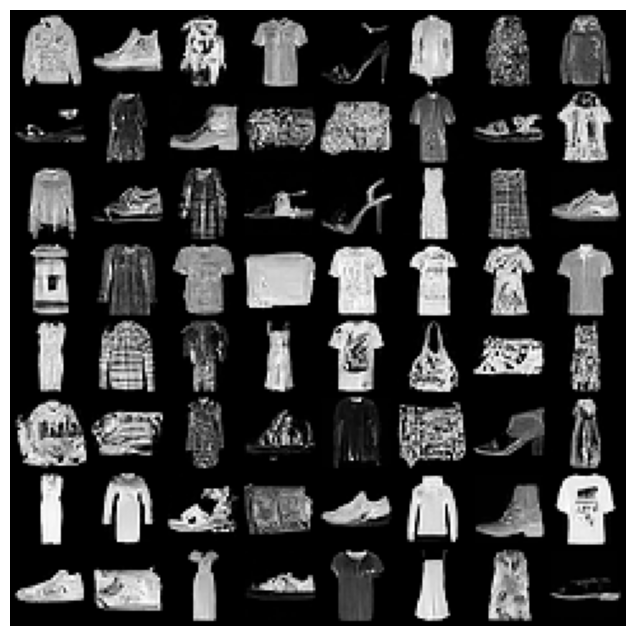


Last 5 log lines:
99996,0.06902411580085754,0.14901949515409127,66.74149196440713
99997,0.09354110807180405,0.1288669398676867,66.74170948815414
99998,0.06580547988414764,0.1936909373363915,66.74190473615229
99999,0.05950590968132019,0.06808360404473848,66.74209074347557
100000,0.05058756470680237,0.08031250236914463,66.74226710483015


In [10]:
sample_files = sorted((OUT_DIR / "samples").glob("step_*.png"))
if sample_files:
    img_path = sample_files[-1]
    print("Latest sample grid:", img_path)
    img = plt.imread(str(img_path))
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.show()
else:
    print("No sample grids found yet.")

if log_path.exists():
    with log_path.open("r") as f:
        lines = f.readlines()
    print("\nLast 5 log lines:")
    for line in lines[-5:]:
        print(line.strip())


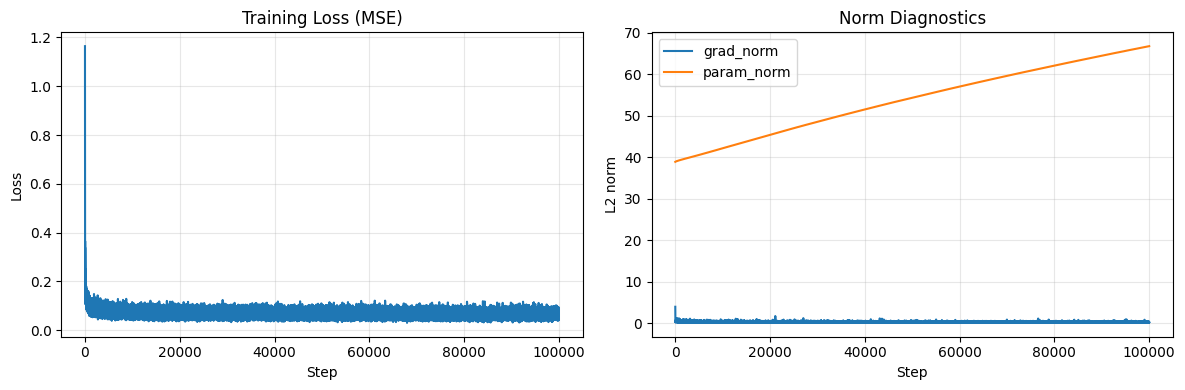

In [11]:
import csv

steps, losses, grad_norms, param_norms = [], [], [], []

if not log_path.exists():
    print("Log file not found:", log_path)
else:
    with log_path.open("r", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            steps.append(int(row["step"]))
            losses.append(float(row["loss"]))
            grad_norms.append(float(row["grad_norm"]))
            param_norms.append(float(row["param_norm"]))

    if len(steps) == 0:
        print("Log file is empty.")
    else:
        fig, ax = plt.subplots(1, 2, figsize=(12, 4))

        ax[0].plot(steps, losses)
        ax[0].set_title("Training Loss (MSE)")
        ax[0].set_xlabel("Step")
        ax[0].set_ylabel("Loss")
        ax[0].grid(alpha=0.3)

        ax[1].plot(steps, grad_norms, label="grad_norm")
        ax[1].plot(steps, param_norms, label="param_norm")
        ax[1].set_title("Norm Diagnostics")
        ax[1].set_xlabel("Step")
        ax[1].set_ylabel("L2 norm")
        ax[1].legend()
        ax[1].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()